# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [4]:
batch_size = 256
epochs = 25
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = (256,)

n_fc = 1
fc_hidden = (64,)


h5_path = Path("../outputs/datasets/lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5")
out_dir = Path("../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [5]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=tuple(lstm_hidden),
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\lstm_merged_batches_0001_k5_standard_train0.70_val0.15_test0.15.h5
  Batch size:      256
  Seed:            123

  Train profiles:  700
  Val profiles:    150
  Test profiles:   150

  Sample X shape:  (2001, 6, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   1,400,700  (~5,472 batches)
  Val samples:     300,150  (~1,173 batches)
  Test samples:    300,150  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          5472
    val_samples:    1173
    val_profile_ds: 150
    test_profile_ds:150

Train batch X shape: torch.Size([256, 6, 14])
Train batch Y shape: torch.Size([256, 13])

Val profile: results_drum_profile_00008
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 6, 14])
  Y profile shape: torch.Size([2001, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): [256]
  FC layers (1): [64]
  Output targets: 13



Train 1/25: 5472batch [00:22, 241.62batch/s, loss=0.001290]
Val 1/25: 1173batch [00:02, 420.28batch/s]


Epoch 1/25 - loss: 0.010623 - val_loss: 0.015768 - data_time: 0.00s - compute_time: 9.68s - val_time: 2.79s - max_cuda_mem: 50.04 MB


Train 2/25: 5472batch [00:22, 245.93batch/s, loss=0.000130]
Val 2/25: 1173batch [00:02, 423.93batch/s]


Epoch 2/25 - loss: 0.001006 - val_loss: 0.001472 - data_time: 0.00s - compute_time: 9.48s - val_time: 2.77s - max_cuda_mem: 50.04 MB


...

Epoch 23/25 - loss: 0.000062 - val_loss: 0.000784 - data_time: 0.00s - compute_time: 9.76s - val_time: 2.75s - max_cuda_mem: 50.04 MB


Train 24/25: 5472batch [00:22, 240.32batch/s, loss=0.000019]
Val 24/25: 1173batch [00:02, 420.43batch/s]


Epoch 24/25 - loss: 0.000070 - val_loss: 0.000210 - data_time: 0.00s - compute_time: 9.61s - val_time: 2.79s - max_cuda_mem: 50.04 MB


Train 25/25: 5472batch [00:22, 240.35batch/s, loss=0.000062]
Val 25/25: 1173batch [00:02, 428.26batch/s]


Epoch 25/25 - loss: 0.000072 - val_loss: 0.000655 - data_time: 0.00s - compute_time: 9.61s - val_time: 2.74s - max_cuda_mem: 50.04 MB
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png
Finished training using device: cuda:0


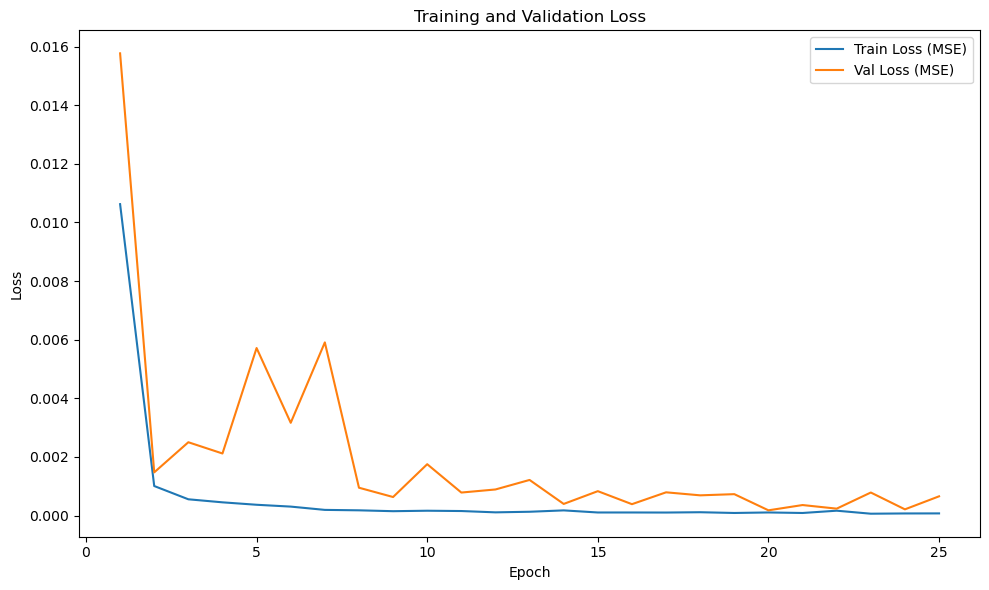

In [6]:
model, history, used_device = pipeline.train(epochs=epochs, out_dir=out_dir)
print(f"Finished training using device: {used_device}")

In [7]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

Forecast profiles: 1profile [00:02,  2.36s/profile, mse=1.132621e+10]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:04,  2.38s/profile, mse=1.561584e+10]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00006.png


Forecast profiles: 3profile [00:06,  2.32s/profile, mse=1.502983e+10]

...

Forecast profiles: 5profile [00:11,  2.33s/profile, mse=1.571825e+10]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00028.png


Forecast profiles: 150profile [02:26,  1.03profile/s, mse=1.258158e+10]


Testing timing summary: total_fetch: 0.0001s -  total_test: 138.0593s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.9204s -  save_time: 0.0519s



{'avg_fetch_profile_s': 4.640008167674144e-07,
 'avg_inference_profile_s': 0.9203950773311469,
 'total_fetch_s': 6.960012251511216e-05,
 'total_test_s': 138.05933119979454,
 'save_time_s': 0.05188169999746606}

In [7]:
if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Clearing cuda:0...
